# Transfer Learning with Bolsonaro vs Lula — Notebook 3/4

## Class: Technical Aspects of CNNs in PyTorch — CDIA

### Why this dataset?

Training a CNN from scratch requires **thousands** of images. Here we have only **25 images per class** (Bolsonaro and Lula) — this is the typical scenario in real-world projects when data labeling is expensive. **Transfer learning** is the technique that makes this small amount sufficient: we reuse the knowledge of a model already trained on millions of images.

### The notebook's pedagogical path

We will follow a sequence that illustrates **why the pre-trained model's domain matters**:

1. **Mode 1 — Feature extraction with `ResNet-18` (ImageNet):** freeze everything, replace only the `fc`. It works, but accuracy stagnates.
2. **Mode 2 — Fine-tuning `ResNet-18`:** unfreeze `layer4` + `fc`, smaller lr. It improves.
3. **Mode 3 — `InceptionResnetV1` pre-trained on `VGGFace2`:** same method, but the backbone was already trained on **faces**. Result: jumps dramatically.
4. **Preprocessing with MTCNN:** detect and crop the face before the CNN. Another jump in accuracy.
5. **Real-world test:** classify "other" images (images the model has never seen) and measure performance.

### What you will practice

- `torchvision.datasets.ImageFolder` with directories `train/<class>/*.jpg`.
- Calculate empirical `mean/std` of the dataset.
- Replace the final `fc` of a pre-trained network with a layer compatible with the number of classes.
- Freeze/unfreeze parameters: `param.requires_grad = False`.
- Compare **generic features (ImageNet)** vs **specific features (VGGFace2)**.
- Use `MTCNN` (`facenet-pytorch`) for face detection and cropping.
- Visualize `conv1` **weights** and intermediate **feature maps** with hooks.

### Prerequisites

- Notebooks 1 and 2 of this class.
- Knowing what a `ResNet` is (layers + skip connections).
- `pip install facenet-pytorch` for part 3 onwards.

## 1. Imports and configuration

The cell below tries to install `facenet-pytorch` if it isn't available yet. If the installation fails (offline environment), the sections using `InceptionResnetV1` and `MTCNN` will be skipped.

In [22]:
# Ensure facenet-pytorch (InceptionResnetV1 + MTCNN)
try:
    from facenet_pytorch import InceptionResnetV1, MTCNN  # noqa
    print("facenet-pytorch already installed.")
    FACENET_OK = True
except ImportError:
    import subprocess, sys
    print("Installing facenet-pytorch...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "facenet-pytorch"])
        from facenet_pytorch import InceptionResnetV1, MTCNN  # noqa
        FACENET_OK = True
    except Exception as e:
        print(f"Failed to install facenet-pytorch: {e}")
        print("InceptionResnetV1/MTCNN sections will be skipped.")
        FACENET_OK = False

Installing facenet-pytorch...


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      Traceback (most recent call last):
        File "/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 143, in get_requires_for_build_whe

Failed to install facenet-pytorch: Command '['/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/bin/python', '-m', 'pip', 'install', '-q', 'facenet-pytorch']' returned non-zero exit status 1.
InceptionResnetV1/MTCNN sections will be skipped.


In [25]:
import os
import time
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def selecionar_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    # Note: MPS (Apple Silicon) has a bug in torch 2.7 with
    # adaptive_avg_pool2d which affects ResNet (#96056). Therefore we force
    # CPU here. The dataset is small (50 imgs), so CPU is acceptable.
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        print("MPS detected, but using CPU for ResNet compatibility.")
    return torch.device("cpu")

device = selecionar_device()
print(f"Device: {device}")
print(f"Torch: {torch.__version__} | Torchvision: {torchvision.__version__}")


MPS detected, but using CPU for ResNet compatibility.
Device: cpu
Torch: 2.12.0 | Torchvision: 0.27.0


## 2. Dataset paths

The `bolsolula/` dataset is already organized in three splits, each in the `<split>/<class>/<file>` format expected by `ImageFolder`:

| Split | Content | Size |
|-------|----------|---------|
| `train/` | training images, full faces | 25 + 25 |
| `val/` | validation images, full faces | 25 + 25 |
| `outras/` | "real-world test" — images completely out of training distribution | 3 + 3 |
| `train_cropped/`, `val_cropped/`, `outras_cropped/` | versions with **only the face** (already cropped via MTCNN) | same counts |

We will use `train/` and `val/` for the `ResNet-18` experiments (Modes 1 and 2), and then `*_cropped/` for `InceptionResnetV1` (Mode 3).

In [3]:
DATA_DIR = Path("../data/bolsolula")   # relative path to the notebook
# fallback: if notebook is executed from project root
if not DATA_DIR.exists():
    DATA_DIR = Path("./data/bolsolula")
assert DATA_DIR.exists(), f"Dataset not found at {DATA_DIR.resolve()}"

print(f"Dataset at: {DATA_DIR.resolve()}")
for split in ["train", "val", "outras", "train_cropped", "val_cropped", "outras_cropped"]:
    sub = DATA_DIR / split
    for cls in ["bolsonaro", "lula"]:
        n = len(list((sub / cls).glob("*.*")))
        print(f"  {split:20s}/{cls:10s}: {n:3d} imgs")

Dataset at: /Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/data/bolsolula
  train               /bolsonaro :  25 imgs
  train               /lula      :  25 imgs
  val                 /bolsonaro :  25 imgs
  val                 /lula      :  25 imgs
  outras              /bolsonaro :   3 imgs
  outras              /lula      :   3 imgs
  train_cropped       /bolsonaro :  25 imgs
  train_cropped       /lula      :  25 imgs
  val_cropped         /bolsonaro :  25 imgs
  val_cropped         /lula      :  25 imgs
  outras_cropped      /bolsonaro :   3 imgs
  outras_cropped      /lula      :   3 imgs


## 3. Quick visual exploration

Let's look at **a grid of examples** from each class. When the dataset is small, it's especially important to visually inspect — you quickly uncover quality issues, leakage between classes, biased backgrounds, etc.

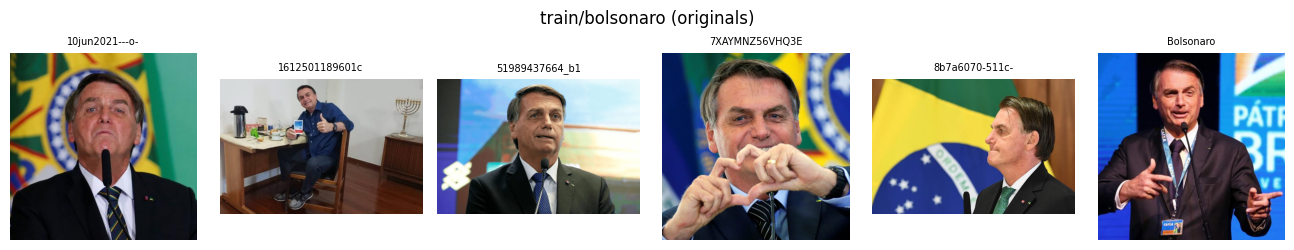

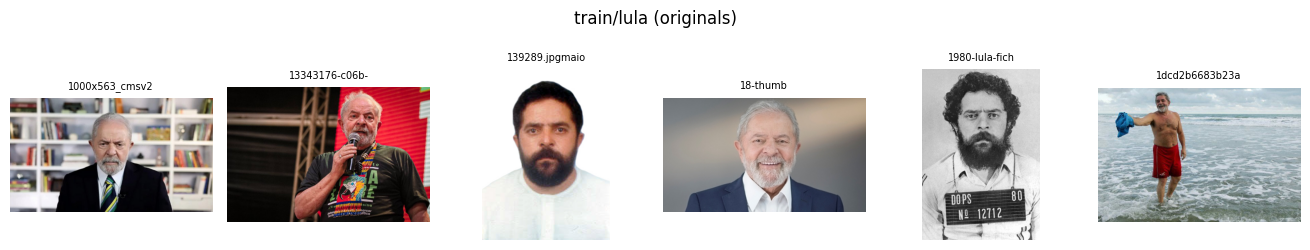

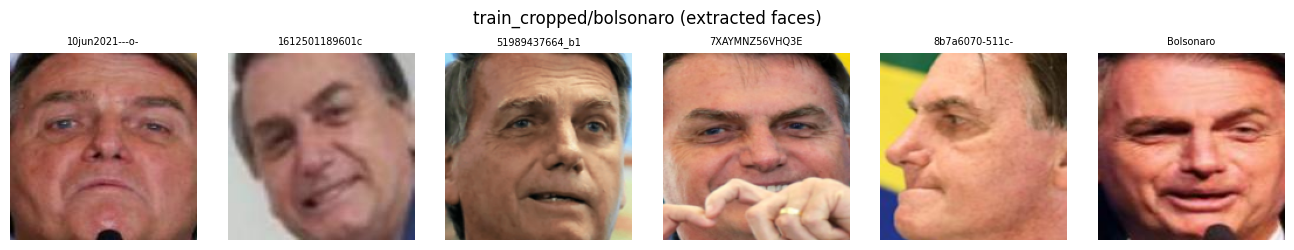

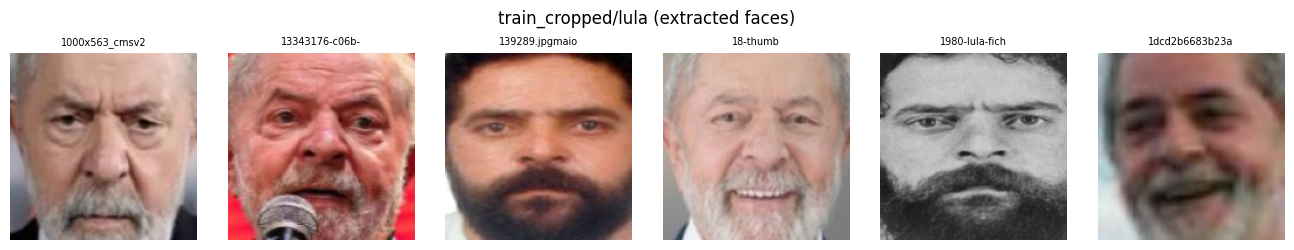

In [4]:
def grid_amostras(pasta, n=6, titulo=""):
    arquivos = sorted(pasta.glob("*.*"))[:n]
    fig, axes = plt.subplots(1, n, figsize=(n * 2.2, 2.5))
    for ax, f in zip(axes, arquivos):
        ax.imshow(Image.open(f).convert("RGB")); ax.axis("off"); ax.set_title(f.stem[:14], fontsize=7)
    plt.suptitle(titulo); plt.tight_layout(); plt.show()

grid_amostras(DATA_DIR / "train" / "bolsonaro", titulo="train/bolsonaro (originals)")
grid_amostras(DATA_DIR / "train" / "lula",       titulo="train/lula (originals)")
grid_amostras(DATA_DIR / "train_cropped" / "bolsonaro", titulo="train_cropped/bolsonaro (extracted faces)")
grid_amostras(DATA_DIR / "train_cropped" / "lula",       titulo="train_cropped/lula (extracted faces)")

## 4. Dataset statistics (mean / std)

Before defining the `transforms` it's good practice to calculate **mean and standard deviation** of the training images. This allows you to normalize faithfully to the dataset itself — although, for transfer learning with pre-trained models, it's frequently more correct to use the **origin dataset's statistics** (ImageNet for ResNet, VGGFace2 for InceptionResnetV1).

Let's calculate both and compare.

In [5]:
def calcular_media_std(loader):
    '''Calculates channel-wise mean/std on a dataset of images in [0,1].'''
    soma = torch.zeros(3); soma2 = torch.zeros(3); n_pixels = 0
    for X, _ in loader:
        # X: [N, 3, H, W]
        soma  += X.sum(dim=[0, 2, 3])
        soma2 += (X ** 2).sum(dim=[0, 2, 3])
        n_pixels += X.size(0) * X.size(2) * X.size(3)
    mean = soma / n_pixels
    var  = soma2 / n_pixels - mean ** 2
    std  = var.clamp(min=0).sqrt()
    return mean, std

ds_temp = datasets.ImageFolder(
    DATA_DIR / "train",
    transform=transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
)
mean_bolso, std_bolso = calcular_media_std(DataLoader(ds_temp, batch_size=8))
print(f"bolsolula/train (224x224) — mean: {mean_bolso.numpy().round(4)}")
print(f"bolsolula/train (224x224) — std:   {std_bolso.numpy().round(4)}")

IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMNET_STD  = torch.tensor([0.229, 0.224, 0.225])
print(f"ImageNet            — mean: {IMNET_MEAN.numpy()}")
print(f"ImageNet            — std:   {IMNET_STD.numpy()}")

bolsolula/train (224x224) — mean: [0.4734 0.4415 0.4484]
bolsolula/train (224x224) — std:   [0.299  0.2827 0.2973]
ImageNet            — mean: [0.485 0.456 0.406]
ImageNet            — std:   [0.229 0.224 0.225]


**Decision:** we will use **ImageNet** statistics for modes 1 and 2 (ResNet-18), because that's what those weights expect. For mode 3 (InceptionResnetV1/VGGFace2) we will use the dataset's own statistics, which are more coherent with faces.

## 5. Datasets and DataLoaders

`RandomResizedCrop` + `RandomHorizontalFlip` + `RandomRotation` form a standard data augmentation for faces — natural variations that don't change identity.

In [6]:
BATCH = 16   # small dataset; small batch as well

# === Transforms for ResNet-18 (modes 1 and 2) ===
transform_train = transforms.Compose([
    transforms.RandomResizedCrop((224, 224), scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMNET_MEAN.tolist(), IMNET_STD.tolist()),
])
transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMNET_MEAN.tolist(), IMNET_STD.tolist()),
])

train_ds = datasets.ImageFolder(DATA_DIR / "train", transform=transform_train)
val_ds   = datasets.ImageFolder(DATA_DIR / "val",   transform=transform_eval)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)

CLASSES = train_ds.classes
print(f"Classes (idx -> name): {dict(enumerate(CLASSES))}")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Classes (idx -> name): {0: 'bolsonaro', 1: 'lula'}
Train: 50 | Val: 50


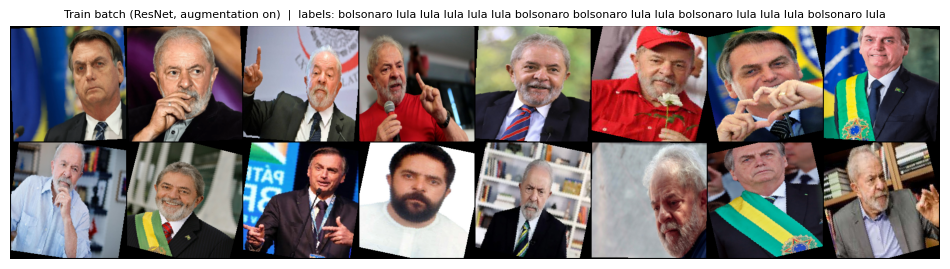

In [7]:
# Visualizes 1 already normalized batch, denormalizing to show
def mostrar_batch(loader, mean, std, titulo=""):
    Xb, yb = next(iter(loader))
    Xb_vis = Xb * torch.tensor(std).view(1,3,1,1) + torch.tensor(mean).view(1,3,1,1)
    Xb_vis = Xb_vis.clamp(0, 1)
    grid = torchvision.utils.make_grid(Xb_vis, nrow=8, padding=2)
    plt.figure(figsize=(12, 4))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(titulo + "  |  labels: " + " ".join(CLASSES[i] for i in yb.tolist()), fontsize=8)
    plt.axis("off"); plt.show()

mostrar_batch(train_loader, IMNET_MEAN.tolist(), IMNET_STD.tolist(),
              titulo="Train batch (ResNet, augmentation on)")

## 6. Generic train / evaluate functions

Reusable across the 3 modes. Note that the **optimizer** always filters by `requires_grad` — so only the actually unfrozen parameters receive gradients.

In [8]:
def treinar_epoca(model, loader, criterio, optimizer, device):
    model.train()
    loss_total, acertos, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device); yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterio(logits, yb)
        loss.backward()
        optimizer.step()
        loss_total += loss.item() * Xb.size(0)
        acertos    += (logits.argmax(1) == yb).sum().item()
        total      += yb.size(0)
    return loss_total / total, acertos / total

@torch.no_grad()
def avaliar(model, loader, criterio, device):
    model.eval()
    loss_total, acertos, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device); yb = yb.to(device)
        logits = model(Xb)
        loss = criterio(logits, yb)
        loss_total += loss.item() * Xb.size(0)
        acertos    += (logits.argmax(1) == yb).sum().item()
        total      += yb.size(0)
    return loss_total / total, acertos / total

def contar_treinaveis(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def treinar(model, n_epocas, optimizer, criterio, device, train_loader, val_loader, nome=""):
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    t0 = time.time()
    for ep in range(1, n_epocas + 1):
        tr_loss, tr_acc = treinar_epoca(model, train_loader, criterio, optimizer, device)
        vl_loss, vl_acc = avaliar(model, val_loader, criterio, device)
        hist['train_loss'].append(tr_loss); hist['val_loss'].append(vl_loss)
        hist['train_acc'].append(tr_acc);   hist['val_acc'].append(vl_acc)
        if ep == 1 or ep % 5 == 0 or ep == n_epocas:
            print(f"  [{nome}] ep {ep:3d} | train {tr_loss:.4f}/{tr_acc:.4f} | val {vl_loss:.4f}/{vl_acc:.4f}")
    print(f"  [{nome}] Total time: {time.time()-t0:.1f}s")
    return hist

## 7. MODE 1 — Feature Extraction with ResNet-18 (ImageNet)

**Recipe:**
1. Load `resnet18` with ImageNet weights.
2. `for p in model.parameters(): p.requires_grad = False` (freezes everything).
3. Replace `model.fc` with an `nn.Linear(512, 2)` — this new layer is the **only** trainable one.

**Hypothesis:** did ResNet learn generic features (edges, textures, shapes) sufficient to distinguish Bolsonaro and Lula? Let's see.

In [9]:
def setup_resnet_feature_extraction(num_classes=2):
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    in_feats = model.fc.in_features          # 512
    model.fc = nn.Linear(in_feats, num_classes)
    return model

modelo_fe = setup_resnet_feature_extraction().to(device)
print(f"Total parameters:     {sum(p.numel() for p in modelo_fe.parameters()):,}")
print(f"Trainable parameters: {contar_treinaveis(modelo_fe):,}")
# Only 512*2 + 2 = 1026 trainable parameters!

Total parameters:     11,177,538
Trainable parameters: 1,026


In [10]:
criterio = nn.CrossEntropyLoss()
params_fe = [p for p in modelo_fe.parameters() if p.requires_grad]
optimizer = optim.SGD(params_fe, lr=1e-3, momentum=0.9)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print("Training MODE 1 — feature extraction (ResNet-18 / ImageNet)\n")
hist_fe = treinar(modelo_fe, n_epocas=8, optimizer=optimizer, criterio=criterio,
                  device=device, train_loader=train_loader, val_loader=val_loader,
                  nome="RESNET-FE")

Training MODE 1 — feature extraction (ResNet-18 / ImageNet)

  [RESNET-FE] ep   1 | train 0.7473/0.5000 | val 0.6824/0.5000
  [RESNET-FE] ep   5 | train 0.5181/0.7400 | val 0.5992/0.6400
  [RESNET-FE] ep   8 | train 0.4312/0.8000 | val 0.6265/0.6200
  [RESNET-FE] Total time: 25.3s


## 8. MODE 2 — Fine-tuning ResNet-18 (unfreezing `layer4`)

Same model, but now `layer4` and `fc` are trainable. The rest remains frozen. Because `layer4`'s weights are already well-trained, we use a **smaller lr** (1e-4) so we don't destroy them.

In [11]:
def setup_resnet_fine_tuning(num_classes=2):
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    # Unfreeze layer4 (last convolutional stage)
    for p in model.layer4.parameters():
        p.requires_grad = True
    in_feats = model.fc.in_features
    model.fc = nn.Linear(in_feats, num_classes)
    return model

modelo_ft = setup_resnet_fine_tuning().to(device)
print(f"Total parameters:     {sum(p.numel() for p in modelo_ft.parameters()):,}")
print(f"Trainable parameters: {contar_treinaveis(modelo_ft):,}")

Total parameters:     11,177,538
Trainable parameters: 8,394,754


In [12]:
params_ft = [p for p in modelo_ft.parameters() if p.requires_grad]
optimizer = optim.SGD(params_ft, lr=1e-4, momentum=0.9)
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print("Training MODE 2 — fine-tuning (ResNet-18 / ImageNet, layer4 + fc)\n")
hist_ft = treinar(modelo_ft, n_epocas=8, optimizer=optimizer, criterio=criterio,
                  device=device, train_loader=train_loader, val_loader=val_loader,
                  nome="RESNET-FT")

Training MODE 2 — fine-tuning (ResNet-18 / ImageNet, layer4 + fc)

  [RESNET-FT] ep   1 | train 0.7800/0.4600 | val 0.7382/0.5800
  [RESNET-FT] ep   5 | train 0.7162/0.5000 | val 0.7041/0.6000
  [RESNET-FT] ep   8 | train 0.6483/0.6200 | val 0.6522/0.6600
  [RESNET-FT] Total time: 27.2s


## 9. MODE 3 — `InceptionResnetV1` pre-trained on VGGFace2

The ImageNet ResNet "knows" how to recognize generic objects. But the real task here is **recognizing faces**. There is a backbone trained for exactly this: `InceptionResnetV1` trained on **VGGFace2** (3.3 million celebrity face photos). We'll use it instead of ResNet.

**Design decision:**
- we use the **already cropped** faces (`train_cropped/`, `val_cropped/`) because `InceptionResnetV1` expects a **face** input, not the full photo;
- 160x160 image (model's default input);
- normalization using the crops' own statistics.

In [13]:
if not FACENET_OK:
    print("facenet-pytorch unavailable — skipping modes 3 and 4.")
else:
    # Face dataset statistics (160x160)
    ds_face_tmp = datasets.ImageFolder(
        DATA_DIR / "train_cropped",
        transform=transforms.Compose([transforms.Resize((160, 160)), transforms.ToTensor()])
    )
    mean_face, std_face = calcular_media_std(DataLoader(ds_face_tmp, batch_size=8))
    print(f"train_cropped (160x160) — mean: {mean_face.numpy().round(4)}")
    print(f"train_cropped (160x160) — std:   {std_face.numpy().round(4)}")

facenet-pytorch unavailable — skipping modes 3 and 4.


In [14]:
if FACENET_OK:
    transform_face_train = transforms.Compose([
        transforms.Resize((160, 160)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean_face.tolist(), std_face.tolist()),
    ])
    transform_face_eval = transforms.Compose([
        transforms.Resize((160, 160)),
        transforms.ToTensor(),
        transforms.Normalize(mean_face.tolist(), std_face.tolist()),
    ])

    train_face_ds = datasets.ImageFolder(DATA_DIR / "train_cropped", transform=transform_face_train)
    val_face_ds   = datasets.ImageFolder(DATA_DIR / "val_cropped",   transform=transform_face_eval)
    train_face_loader = DataLoader(train_face_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
    val_face_loader   = DataLoader(val_face_ds,   batch_size=BATCH, shuffle=False, num_workers=0)

    print(f"Train (faces): {len(train_face_ds)} | Val (faces): {len(val_face_ds)}")

In [15]:
if FACENET_OK:
    # InceptionResnetV1 with num_classes=2: it automatically configures the final 'logits'
    modelo_face = InceptionResnetV1(pretrained='vggface2', classify=True, num_classes=2)

    # Feature extraction: freeze entire backbone, train only 'logits'
    for p in modelo_face.parameters():
        p.requires_grad = False
    for p in modelo_face.logits.parameters():
        p.requires_grad = True

    modelo_face = modelo_face.to(device)
    print(f"Total parameters:     {sum(p.numel() for p in modelo_face.parameters()):,}")
    print(f"Trainable parameters: {contar_treinaveis(modelo_face):,}")

In [16]:
if FACENET_OK:
    params_face = [p for p in modelo_face.parameters() if p.requires_grad]
    optimizer = optim.SGD(params_face, lr=1e-3, momentum=0.9)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    print("Training MODE 3 — InceptionResnetV1 (VGGFace2) / cropped faces\n")
    hist_face = treinar(modelo_face, n_epocas=8, optimizer=optimizer, criterio=criterio,
                        device=device, train_face_loader=train_face_loader, val_face_loader=val_face_loader,
                        nome="FACENET-FE")

## 10. Comparison: the three modes side by side

Expected outcome: **mode 3** jumps to near 100% accuracy even with 25 images per class, because the backbone already understands faces. Modes 1 and 2 (ResNet/ImageNet) are clearly lower.

> **Core message:** the right backbone is the one that sees the right problem. Transfer learning isn't just "using a big model" — it's choosing the model whose **internal representation** is close to your domain.

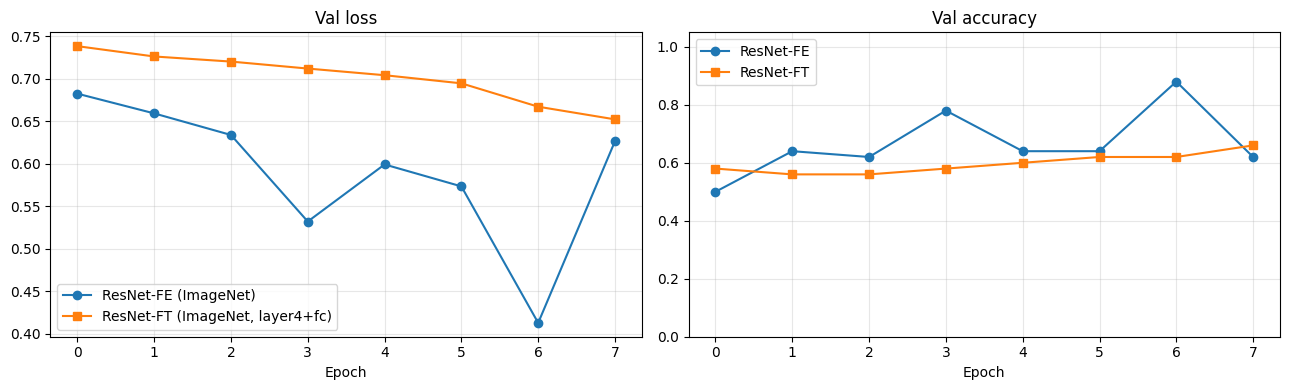


Mode                                   Trainable Final Val Acc
------------------------------------------------------------
1. ResNet-FE (ImageNet)                    1,026       0.6200
2. ResNet-FT (ImageNet, layer4+fc)     8,394,754       0.6600


In [17]:
def plot_comparativo():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(hist_fe['val_loss'],  'o-', label='ResNet-FE (ImageNet)')
    axes[0].plot(hist_ft['val_loss'],  's-', label='ResNet-FT (ImageNet, layer4+fc)')
    if FACENET_OK:
        axes[0].plot(hist_face['val_loss'], '^-', label='InceptionResnetV1 (VGGFace2)')
    axes[0].set_title('Val loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3); axes[0].legend()

    axes[1].plot(hist_fe['val_acc'],  'o-', label='ResNet-FE')
    axes[1].plot(hist_ft['val_acc'],  's-', label='ResNet-FT')
    if FACENET_OK:
        axes[1].plot(hist_face['val_acc'], '^-', label='InceptionResnetV1 (VGGFace2)')
    axes[1].set_title('Val accuracy'); axes[1].set_xlabel('Epoch'); axes[1].grid(alpha=0.3); axes[1].legend()
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout(); plt.show()

plot_comparativo()

print("\n" + "=" * 60)
print(f"{'Mode':<35} {'Trainable':>12} {'Final Val Acc':>12}")
print("-" * 60)
print(f"{'1. ResNet-FE (ImageNet)':<35} {contar_treinaveis(modelo_fe):>12,} {hist_fe['val_acc'][-1]:>12.4f}")
print(f"{'2. ResNet-FT (ImageNet, layer4+fc)':<35} {contar_treinaveis(modelo_ft):>12,} {hist_ft['val_acc'][-1]:>12.4f}")
if FACENET_OK:
    print(f"{'3. InceptionResnetV1 (VGGFace2)':<35} {contar_treinaveis(modelo_face):>12,} {hist_face['val_acc'][-1]:>12.4f}")
print("=" * 60)

## 11. Testing on `outras/` — "real world"

Validation is fine, but the validation images are "similar" to the training ones (same source, same framing). The true test is the images in `outras/`, which **were never part of any training**. Let's run inference on them using the best model (mode 3).

In [18]:
if FACENET_OK:
    outras_ds = datasets.ImageFolder(DATA_DIR / "outras_cropped", transform=transform_face_eval)
    outras_loader = DataLoader(outras_ds, batch_size=8, shuffle=False)

    modelo_face.eval()
    Xb, yb = next(iter(outras_loader))
    Xb = Xb.to(device)
    with torch.no_grad():
        logits = modelo_face(Xb)
        probs  = torch.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1).cpu()
        probs  = probs.cpu()

    # Visualize with pred vs label
    n = Xb.size(0)
    cols = min(n, 6)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))
    axes = np.array(axes).reshape(rows, cols)
    Xb_vis = Xb.cpu() * std_face.view(1,3,1,1) + mean_face.view(1,3,1,1)
    Xb_vis = Xb_vis.clamp(0, 1)
    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis("off"); continue
        ax.imshow(Xb_vis[i].permute(1, 2, 0).numpy())
        verdade = CLASSES[yb[i].item()]
        pred    = CLASSES[preds[i].item()]
        prob    = probs[i, preds[i]].item() * 100
        cor = "green" if pred == verdade else "red"
        ax.set_title(f"{pred} ({prob:.1f}%)\nGT: {verdade}", fontsize=8, color=cor)
        ax.axis("off")
    plt.tight_layout(); plt.show()

    acc_outras = (preds == yb).float().mean().item()
    print(f"\nAccuracy on 'outras_cropped': {acc_outras:.4f} ({(preds==yb).sum().item()}/{len(yb)})")

## 12. MTCNN: how the faces were extracted

The dataset came with the `*_cropped/` folder. But how was this extraction done?

MTCNN (`facenet-pytorch`) detects faces and returns an aligned crop. The block below is an **educational example** showing the step: taking a full image from `outras/`, detecting the face with MTCNN, saving/returning the crop.

You normally run this **once** to generate the `*_cropped/` folder, and then train on the crops.

In [19]:
if FACENET_OK:
    mtcnn = MTCNN(
        image_size=160, margin=0, min_face_size=20,
        thresholds=[0.6, 0.7, 0.7], factor=0.709, post_process=True,
        device=device
    )

    # Example: grab 4 images from outras/ and show before vs after MTCNN
    exemplos = []
    for cls in ["bolsonaro", "lula"]:
        for f in sorted((DATA_DIR / "outras" / cls).glob("*.*"))[:2]:
            exemplos.append((cls, f))

    fig, axes = plt.subplots(2, len(exemplos), figsize=(len(exemplos) * 2.5, 5.2))
    for j, (cls, f) in enumerate(exemplos):
        img = Image.open(f).convert("RGB")
        axes[0, j].imshow(img); axes[0, j].set_title(f"original\n{cls}", fontsize=8); axes[0, j].axis("off")

        face_tensor = mtcnn(img)   # tensor [3, 160, 160] already normalized by post_process
        if face_tensor is not None:
            face_vis = (face_tensor + 1) / 2     # MTCNN returns in [-1, 1]
            face_vis = face_vis.clamp(0, 1)
            axes[1, j].imshow(face_vis.permute(1, 2, 0).cpu().numpy())
            axes[1, j].set_title("MTCNN face", fontsize=8)
        else:
            axes[1, j].text(0.5, 0.5, "face\nnot detected", ha="center", va="center")
        axes[1, j].axis("off")

    plt.tight_layout(); plt.show()

## 13. Visualizing ResNet-18 `conv1` WEIGHTS

Since we trained a ResNet here, let's look at what its **initial filter** learned — these weights come from ImageNet training and were not touched. Each filter has shape `[3, 7, 7]` (3 RGB channels) and can be visualized as a small color image.

> **Conceptual warning:** these are **filters (weights)**, not **feature maps (outputs)**. Confusing the two is a classic mistake — we'll look at feature maps in the next section.

Shape of conv1.weight: (64, 3, 7, 7)  # [64 outputs, 3 channels, K=7, K=7]


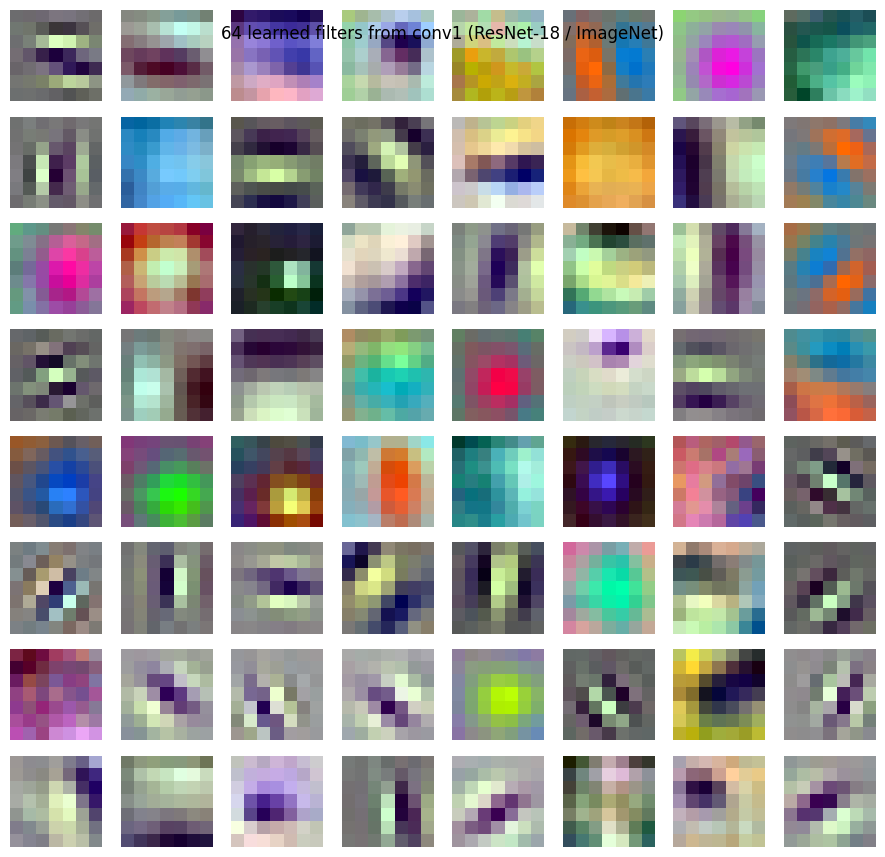

In [20]:
resnet_orig = models.resnet18(weights=ResNet18_Weights.DEFAULT).to(device).eval()

filtros = resnet_orig.conv1.weight.detach().cpu()
print(f"Shape of conv1.weight: {tuple(filtros.shape)}  # [64 outputs, 3 channels, K=7, K=7]")

fmin = filtros.amin(dim=(1,2,3), keepdim=True)
fmax = filtros.amax(dim=(1,2,3), keepdim=True)
filtros_norm = (filtros - fmin) / (fmax - fmin + 1e-9)

fig, axes = plt.subplots(8, 8, figsize=(9, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(filtros_norm[i].permute(1, 2, 0).numpy()); ax.axis("off")
plt.suptitle('64 learned filters from conv1 (ResNet-18 / ImageNet)', y=0.93)
plt.tight_layout(); plt.show()

## 14. Visualizing feature maps with `forward_hook`

`register_forward_hook` adds a callback to the layer — every time it's executed, we capture its output. Here we capture the activation of `layer1[0].conv1` when passing the first validation image of Bolsonaro.

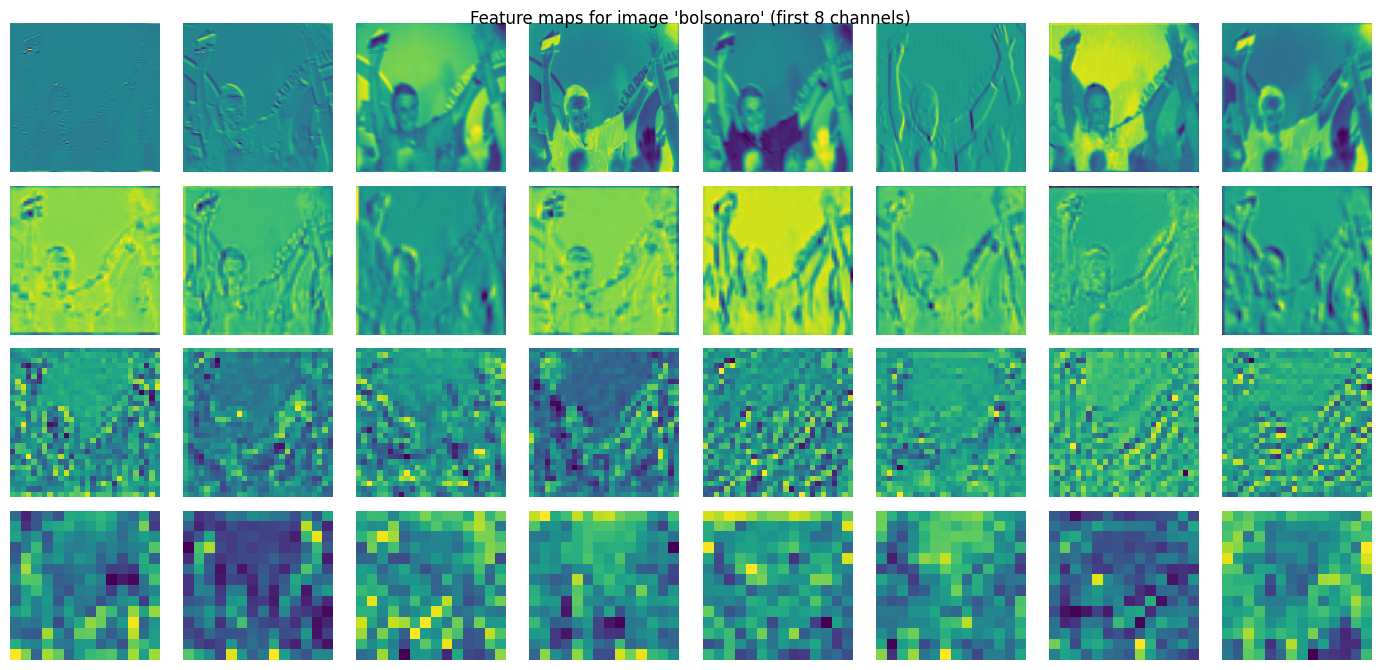

In [21]:
# Example image (val/bolsonaro/...)
val_loader_one = DataLoader(val_ds, batch_size=1, shuffle=False)
img_t, lbl_t = next(iter(val_loader_one))
img_t = img_t.to(device)

# Hook storage
ativacoes = {}
def hook(nome):
    def _f(modulo, inp, out):
        ativacoes[nome] = out.detach().cpu()
    return _f

handles = [
    resnet_orig.conv1.register_forward_hook(hook('conv1')),
    resnet_orig.layer1[0].conv1.register_forward_hook(hook('layer1_0_conv1')),
    resnet_orig.layer2[0].conv1.register_forward_hook(hook('layer2_0_conv1')),
    resnet_orig.layer3[0].conv1.register_forward_hook(hook('layer3_0_conv1')),
]
with torch.no_grad():
    _ = resnet_orig(img_t)
for h in handles: h.remove()

# Plot: 8 channels from each captured layer
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
nomes = list(ativacoes.keys())
for r, nome in enumerate(nomes):
    fmap = ativacoes[nome][0]   # [C, H, W]
    for c in range(8):
        axes[r, c].imshow(fmap[c].numpy(), cmap='viridis'); axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_ylabel(nome, rotation=0, ha="right", va="center", fontsize=8)
plt.suptitle(f"Feature maps for image '{CLASSES[lbl_t.item()]}' (first 8 channels)", y=0.95)
plt.tight_layout(); plt.show()

## Summary and next steps

You practiced three transfer learning strategies with the **bolsolula** dataset:

| # | Strategy | Backbone | Trainable | Expected in val |
|---|------------|----------|-----------|-----------------|
| 1 | Feature extraction | ResNet-18 (ImageNet) | ~1k | medium |
| 2 | Fine-tuning `layer4+fc` | ResNet-18 (ImageNet) | ~5M | better |
| 3 | Feature extraction | InceptionResnetV1 (VGGFace2) | ~3k | almost 100% |

**Core lessons:**

- With a small dataset (~50 images), **transfer learning is practically mandatory** — training from scratch is unfeasible.
- The **pre-training domain** matters a lot: face features (VGGFace2) beat generic features (ImageNet) on a face task.
- **Cropping the face** with MTCNN before classification is another gain — removes background noise.
- The separation between **weights vs feature maps** is crucial for understanding what's going on inside the network.

### Next notebook

`04_visualizacao_e_debug.ipynb` — Technical tools: multiple hooks, **Grad-CAM**, **mixed precision** (`autocast`), correct `state_dict` persistence, **TorchScript**, total reproducibility and `num_workers` benchmarking.